# 02 - EDA
Khám phá dữ liệu tổng quan ở mức order-level: delivery performance và kiểm tra chất lượng dữ liệu theo thời gian.
Phần RFM segmentation được tách riêng sang `03_rfm_segmentation.ipynb`.

## Setup

In [28]:
import pandas as pd
from datetime import date
from src.features import *

In [29]:
order_level = pd.read_parquet("data/processed/order_level.parquet")

In [30]:
order_level.head()

,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_invalid_timestamps,review_score,total_price,total_freight,n_items,n_unique_products,n_unique_sellers,total_payment_value,n_payment_installments,n_payment_methods
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,RJ,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,False,5.0,58.90,13.29,1,1,1,72.19,2.0,1.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,SP,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,False,4.0,239.90,19.93,1,1,1,259.83,3.0,1.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,MG,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,False,5.0,199.00,17.87,1,1,1,216.87,5.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,SP,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,False,4.0,12.99,12.79,1,1,1,25.78,2.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,SP,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,False,5.0,199.90,18.14,1,1,1,218.04,3.0,1.0


In [31]:
order_level.isna().sum()

order_id                            0
customer_id                         0
customer_unique_id                  0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1009
order_delivered_customer_date    2190
order_estimated_delivery_date       0
is_invalid_timestamps               0
review_score                      749
total_price                         0
total_freight                       0
n_items                             0
n_unique_products                   0
n_unique_sellers                    0
total_payment_value                 1
n_payment_installments              1
n_payment_methods                   1
dtype: int64

## Delivery Features

In [32]:
order_level = add_delivery_feature(order_level)

In [33]:
order_level.head()

,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,n_unique_products,n_unique_sellers,total_payment_value,n_payment_installments,n_payment_methods,is_delivered,delivery_time,estimated_delivery_time,delivery_delay,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,RJ,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,...,1,1,72.19,2.0,1.0,True,7.0,15,-9.0,False
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,SP,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,...,1,1,259.83,3.0,1.0,True,16.0,18,-3.0,False
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,MG,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,...,1,1,216.87,5.0,1.0,True,7.0,21,-14.0,False
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,SP,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,...,1,1,25.78,2.0,1.0,True,6.0,11,-6.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,SP,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,...,1,1,218.04,3.0,1.0,True,25.0,40,-16.0,False


In [34]:
invalid_delivered = (order_level['is_delivered'] & order_level['is_invalid_timestamps']).sum()
print(invalid_delivered)

1373


1373 orders have invalid timestamp but still delivered to customers.

In [35]:
n_delivered = order_level['is_delivered'].sum()
n_late = order_level['is_late'].sum()
print(f'Delivered: {n_delivered} \n Late: {n_late} ({n_late / n_delivered * 100:.1f}%)')

Delivered: 96476 
 Late: 6535 (6.8%)


Total 96476 orders delivered, 6535 orders were late (6.8%)

## Order Volume Over Time & Data Quality Check

<Axes: xlabel='order_purchase_timestamp'>

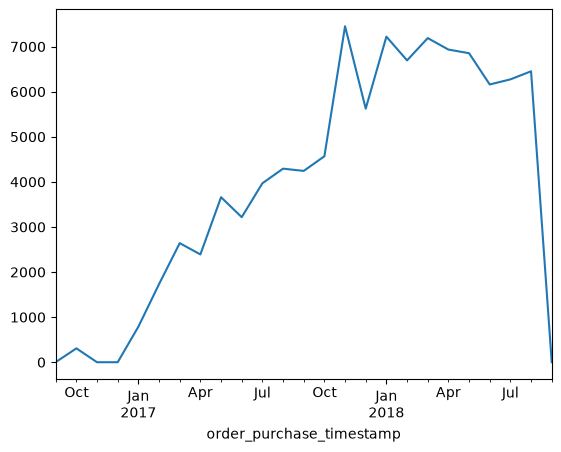

In [36]:
order_level.set_index("order_purchase_timestamp").resample("ME").size().plot()

Finding latest purchase date:

In [37]:
print(order_level["order_purchase_timestamp"].max())

2018-09-03 09:06:57


Date numbers which have data in 4 last months to check which one is lack of days

In [38]:
order_level["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index().tail(4)

order_purchase_timestamp
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: count, dtype: int64

The chart shows continuous growth from 10/2016 to around mid-2018, stabilizing at around 6,000–7,000 orders/month from early 2018. Checking the maximum `order_purchase_timestamp` yields 2018-09-03, and the monthly order volume indicates that September 2018 contains only 1 order — confirming that this is truncated data due to collection limits, rather than an actual business decline. August 2018 (6,452 orders) remains within the normal trend and is unaffected. Therefore, when analyzing time-series trends, records from September 2018 should be removed (retaining data up through the end of August 2018). For RFM analysis, no records need to be removed — recency is calculated relatively among customers, so it is not impacted by an incomplete final month.

<Axes: xlabel='order_purchase_timestamp'>

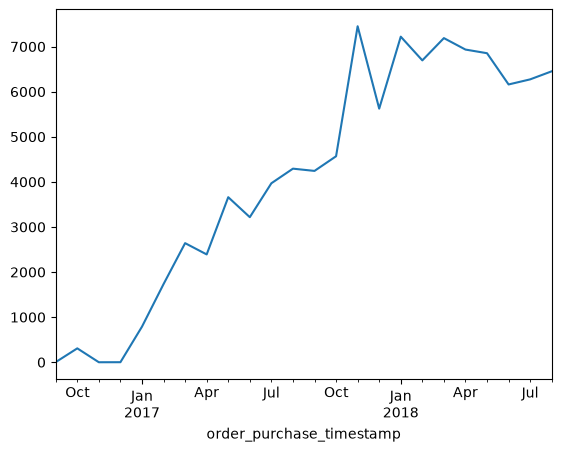

In [39]:
last_complete_month = order_level["order_purchase_timestamp"].max().to_period("M") - 1
order_level_trend = order_level[
    order_level["order_purchase_timestamp"].dt.to_period("M") <= last_complete_month
]

order_level_trend.set_index("order_purchase_timestamp").resample("ME").size().plot()

## Save cleaned/trend-ready data for downstream notebooks

In [40]:
order_level.to_parquet("data/processed/order_level.parquet", index=False)
order_level_trend.to_parquet("data/processed/order_level_trend.parquet", index=False)